# Assignment 2
## Part 2 - Evaluating time series

### 2B - A pair of series: cross-correlation and lead/lag

Dataset 1: RAPID 26°N 
- Project: RAPID-AMOC 26°N array
- Description: RAPID 26N transport estimates dataset
- DOI: https://doi.org/10.5285/48d0bf43-0598-ceb2-e063-7086abc062f1
- Source File: meridional_transports.nc
- Data Product: RAPID meridional transport data
- Time Coverage: 2004-04-06 to 2024-03-22
- Record Length: 730 observations (20.0 years)
- Sampling Frequency: 240.0H -> 10-day low pass filter
- missing: 0.0%

Dataset 2: NOAC 47°N
- Project: Meridional Connectivity of a 25-Year Observational AMOC Record at 47°N
- Description: No description available
- Source File: NOAC_AMOC.tab
- Data Product: Basin-wide AMOC volume transport from the NOAC array at 47°N in the subpolar North Atlantic (1993-2018)
- License: CC-BY-4.0
- Time Coverage: 1993-01-01 to 2018-01-01
- Record Length: 301 observations (25.0 years)
- Sampling Frequency: monthly
- missing: 0.0%

In [1]:
import numpy as np

%load_ext autoreload
%autoreload 2

#### Read data

In [2]:
from amoc_analysis.correlation_trends.data_io import load_47n, load_moc_sigma0_26n

# 26N RAPID overturning in density coordinates: MOC_SIGMA0
rapid_raw = load_moc_sigma0_26n()

# 47N NOAC overturning (monthly) in density coordinates: MOC_SIGMA0
noac_time, noac_values = load_47n()

Loading 1 RAPID 26°N dataset(s):
  0. meridional_transports.nc: RAPID meridional transport data

Loading 1 NOAC 47°N dataset(s):
  0. NOAC_AMOC.tab: Basin-wide AMOC volume transport from the NOAC array at 47°N in the subpolar North Atlantic (1993-2018)



#### Preprocessing

In [3]:
import pandas as pd
import xarray as xr

# put raw arrays into data arrays
rapid = xr.DataArray(
    rapid_raw[1],
    coords={'TIME': ('TIME', pd.to_datetime(rapid_raw[0]))},
    dims='TIME',
)

noac = xr.DataArray(
    noac_values,
    coords={'TIME': ('TIME', pd.to_datetime(noac_time))},
    dims='TIME',
)

# resample RAPID 10-day to monthly
rapid_monthly = rapid.resample(TIME='MS').mean()

# find time overlap
start = max(rapid_monthly.TIME.min(), noac.TIME.min())
end   = min(rapid_monthly.TIME.max(), noac.TIME.max())
print(f'Common period: {start.values} to {end.values}')

# select data from overlap period
rapid_subset = rapid_monthly.sel(TIME=slice(start, end))
noac_subset  = noac.sel(TIME=slice(start, end))

Common period: 2004-04-01T00:00:00.000000000 to 2018-01-01T00:00:00.000000


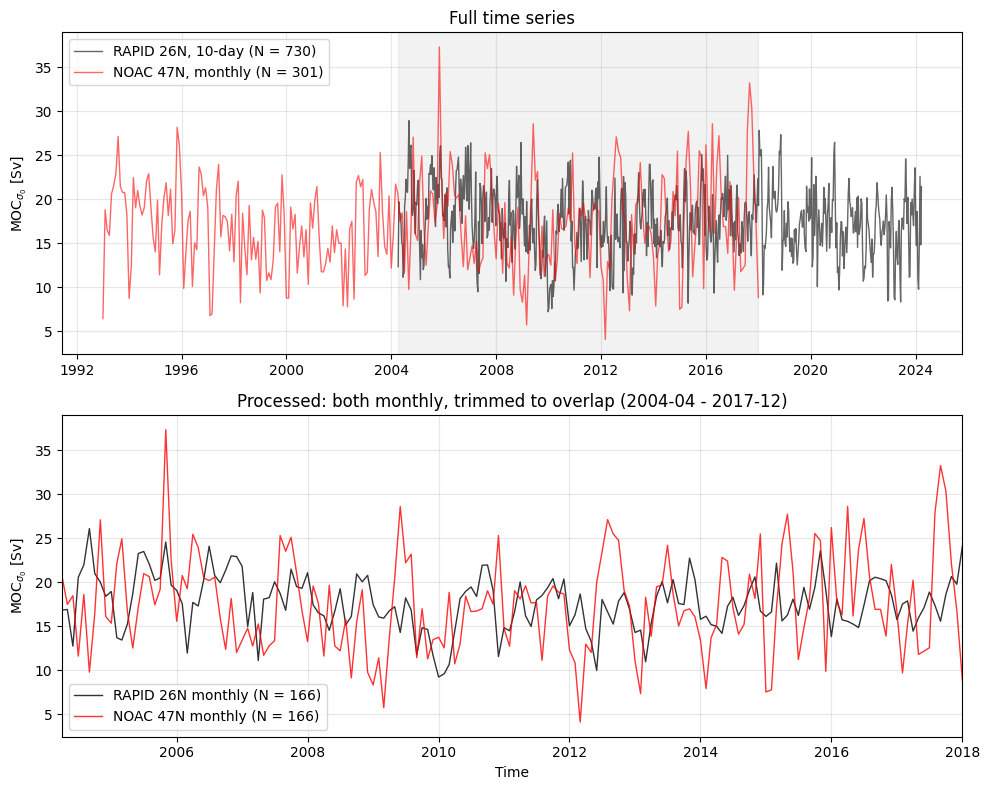

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# plot before: 'raw' data sets
ax1.plot(rapid.TIME, rapid.values, lw=1, alpha=0.6, c='k', label=f'RAPID 26N, 10-day (N = {rapid.sizes['TIME']})')
ax1.plot(noac.TIME, noac.values, lw=1, alpha=0.6, c='r', label=f'NOAC 47N, monthly (N = {noac.sizes['TIME']})')

# highlight overlap time period
ax1.axvspan(start.values, end.values, color='grey', alpha=0.1)

ax1.grid(alpha=0.3)
ax1.set_ylabel('MOC$_{\\sigma_0}$ [Sv]')
ax1.set_title('Full time series')
ax1.legend()

# plot after: monthly, overlap
ax2.plot(rapid_subset.TIME, rapid_subset.values, lw=1, alpha=0.8, c='k', label=f'RAPID 26N monthly (N = {rapid_subset.sizes['TIME']})')
ax2.plot(noac_subset.TIME, noac_subset.values, lw=1, alpha=0.8, c='r', label=f'NOAC 47N monthly (N = {noac_subset.sizes['TIME']})')

ax2.set_xlim(start.values, end.values)
ax2.set_title('Processed: both monthly, trimmed to overlap (2004-04 - 2017-12)')
ax2.set_ylabel('MOC$_{\\sigma_0}$ [Sv]')
ax2.set_xlabel('Time')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.savefig('../plots/fig_2b_before_vs_after.png', bbox_inches='tight')
plt.show()

#### Deseasonalise & cross-correlation

In [5]:
from amoc_analysis.correlation_trends.correlation import cross_correlation
from amoc_analysis.correlation_trends.seasonal import remove_seasonal_cycle

# Deseasonalise data sets
rapid_deseason = remove_seasonal_cycle(da=rapid_subset)
noac_deseason = remove_seasonal_cycle(da=noac_subset)

# Compute cross correlation
lags_raw, cc_raw = cross_correlation(x=rapid_subset, y=noac_subset)
lags_deseason, cc_deseason = cross_correlation(x=rapid_deseason, y=noac_deseason)

# peak correlation and its lag (raw)
i_peak = np.argmax(np.abs(cc_raw))
lag_peak_raw = lags_raw[i_peak]
r_peak_raw = cc_raw[i_peak]
print(f'Raw cross-correlation:\nPeak: |r| = {abs(r_peak_raw):.3f} at lag = {lag_peak_raw} months')

# peak correlation and its lag (deseasonalised)
i_peak = np.argmax(np.abs(cc_deseason))
lag_peak_deseason = lags_deseason[i_peak]
r_peak_deseason = cc_deseason[i_peak]
print(f'\nDeseasoned cross-correlation:\nPeak: |r| = {abs(r_peak_deseason):.3f} at lag = {lag_peak_deseason} months')

Raw cross-correlation:
Peak: |r| = 0.284 at lag = -40 months

Deseasoned cross-correlation:
Peak: |r| = 0.222 at lag = 32 months


- peak lag > 0 -> NOAC leads
- peak lag < 0 -> RAPID leads
- raw cross correlation: RAPID leads
    - still contains seasonal cycles, which could affect result 
    - -40 vs 32 months is a large difference -> not proper lag?
- deseasoned cross correlation: NOAC leads
    - if MOC strengthens at 47N -> MOC at 16N strengthens 32 months (~2.7 years) later
- weakly correlated in both cases, slightly stronger for raw data

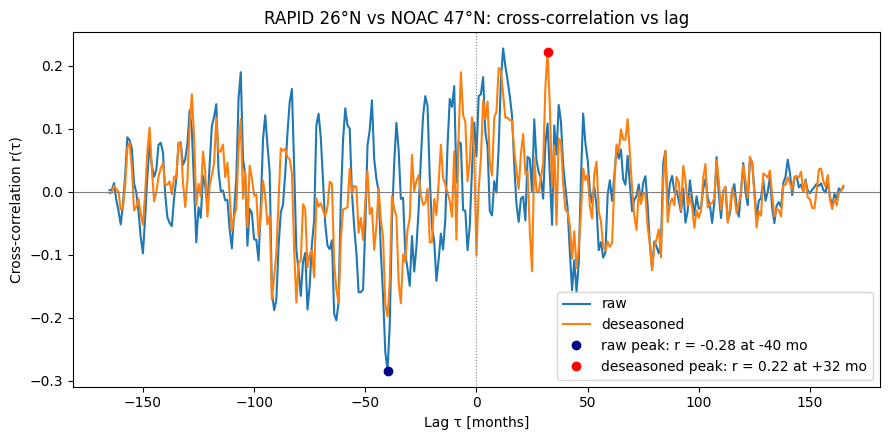

In [6]:
# import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))

# Plot cross-correlation, raw vs deseasonalised
ax.plot(lags_raw, cc_raw, lw=1.5, color='tab:blue', label='raw')
ax.plot(lags_deseason, cc_deseason, lw=1.5, color='tab:orange', label='deseasoned')

# Plot zero-crossings
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8, ls=':')

# Highlight peak lag
ax.plot(lag_peak_raw, r_peak_raw, 'o', color='darkblue', label=f'raw peak: r = {r_peak_raw:.2f} at {lag_peak_raw:+d} mo')
ax.plot(lag_peak_deseason, r_peak_deseason, 'o', color='red', label=f'deseasoned peak: r = {r_peak_deseason:.2f} at {lag_peak_deseason:+d} mo')

ax.set(xlabel='Lag τ [months]',
       ylabel='Cross-correlation r(τ)',
       title='RAPID 26°N vs NOAC 47°N: cross-correlation vs lag')
ax.legend()

fig.tight_layout()
plt.savefig('../plots/fig_2b_crosscorr.png', bbox_inches='tight')
plt.show()

Slope of regression line: -0.19


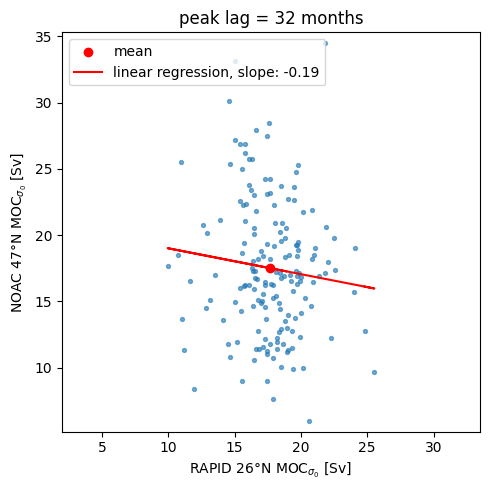

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

x = rapid_deseason.values
y = noac_deseason.values

# scatter plot at peak lag
ax.scatter(x, y, alpha=0.6, s=8)

# Plot means
ax.scatter(np.mean(x), np.mean(y), c='r', marker='o', label='mean')

# Regression line
slope, b = np.polyfit(x,y,1)
print(f'Slope of regression line: {slope:.2f}')
plt.plot(x, slope*x+b, c='r', label=f'linear regression, slope: {slope:.2f}')

# Settings
ax.set_xlabel('RAPID 26°N MOC$_{\\sigma_0}$ [Sv]')
ax.set_ylabel('NOAC 47°N MOC$_{\\sigma_0}$ [Sv]')
ax.set_title(f'peak lag = {lag_peak_deseason} months')
ax.axis('equal')
plt.legend()
plt.tight_layout()

plt.savefig('../plots/fig_2b_scatter.png', bbox_inches='tight')
plt.show()

- no proper trend visible
- nearly horizontal linear regression

-> no significant relationship